# Benchmarking 2D Successive Randomized Compression (2D-SRC) vs. TeNPy (physics-tenpy)

This notebook provides a direct, rigorous benchmark comparing the **2D Successive Randomized Compression (2D-SRC)** algorithm against the industry-standard tensor train library **TeNPy (physics-tenpy)** for MPO-MPS multiplication and compression.

## Environment Setup

We install **TeNPy (`physics-tenpy`)**, which is a highly optimized, pure-Python (with Cython speedups) tensor train library that installs instantly in Google Colab.

In [1]:
# Install TeNPy (installs in a few seconds)
!pip install physics-tenpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 90.6 MB/s eta 0:00:00


## 1. 1D MPO-MPS Contraction Implementations in NumPy

We implement the core 1D MPO-MPS multiplication algorithms in Python using NumPy:
1. **Deterministic SVD:** The standard contract-then-compress baseline.
2. **Randomized 2D-SRC:** The successive randomized compression algorithm.

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Generate random 1D MPS with decaying singular values (modeling physical states)
def generate_random_mps(N, d, chi):
    mps = []
    for i in range(N):
        L = 1 if i == 0 else chi
        R = 1 if i == N - 1 else chi
        A = (np.random.randn(L, d, R) + 1j * np.random.randn(L, d, R)) / np.sqrt(2)
        if L > 1:
            decay_L = np.exp(-0.25 * np.arange(L))
            A = A * decay_L[:, None, None]
        if R > 1:
            decay_R = np.exp(-0.25 * np.arange(R))
            A = A * decay_R[None, None, :]
        mps.append(A / np.linalg.norm(A))
    return mps

# Generate random 1D MPO with decaying singular values
def generate_random_mpo(N, d, D):
    mpo = []
    for i in range(N):
        L = 1 if i == 0 else D
        R = 1 if i == N - 1 else D
        W = (np.random.randn(L, d, d, R) + 1j * np.random.randn(L, d, d, R)) / np.sqrt(2)
        if L > 1:
            decay_L = np.exp(-0.25 * np.arange(L))
            W = W * decay_L[:, None, None, None]
        if R > 1:
            decay_R = np.exp(-0.25 * np.arange(R))
            W = W * decay_R[None, None, None, :]
        mpo.append(W / np.linalg.norm(W))
    return mpo

# Exact uncompressed MPO-MPS multiplication (yielding a large MPS of bond dimension D * chi)
def contract_exact(mpo, mps):
    N = len(mps)
    exact = []
    for i in range(N):
        A, W = mps[i], mpo[i]
        T = np.einsum('lds,uDdr->luDsr', A, W)
        s = T.shape
        exact.append(T.reshape(s[0]*s[1], s[2], s[3]*s[4]))
    return exact

# Compress MPS using standard deterministic SVD sweep (left-to-right)
def compress_deterministic_svd(mps, chi_target, normalize=True):
    N = len(mps)
    compressed = []
    remainder = None
    for i in range(N):
        T = mps[i] if remainder is None else np.tensordot(remainder, mps[i], axes=(1, 0))
        if i < N - 1:
            s = T.shape
            X = T.reshape(-1, s[-1])
            U, S, Vh = np.linalg.svd(X, full_matrices=False)
            c = min(chi_target, U.shape[1])
            compressed.append(U[:, :c].reshape(s[0], s[1], -1))
            remainder = S[:c, None] * Vh[:c, :]
            if normalize:
                norm_rem = np.linalg.norm(remainder)
                if norm_rem > 0:
                    remainder = remainder / norm_rem
        else:
            if normalize:
                norm_t = np.linalg.norm(T)
                if norm_t > 0:
                    T = T / norm_t
            compressed.append(T)
    return compressed

# 2D Successive Randomized Compression (2D-SRC) algorithm implementation
def compress_randomized_src(mpo, mps, chi_target, oversampling=5, normalize=True):
    N = len(mps)
    compressed = []
    remainder = None
    for i in range(N):
        A, W = mps[i], mpo[i]
        T_local = np.einsum('lds,uDdr->luDsr', A, W)
        s = T_local.shape
        T = T_local.reshape(s[0]*s[1], s[2], s[3]*s[4])

        if remainder is not None:
            T = np.tensordot(remainder, T, axes=(1, 0))

        if i < N - 1:
            s_t = T.shape
            X = T.reshape(-1, s_t[-1])
            R_dim = s_t[-1]
            k = min(chi_target + oversampling, R_dim)
            S_mat = (np.random.randn(R_dim, k) + 1j * np.random.randn(R_dim, k)) / np.sqrt(2)
            Y = X @ S_mat
            Q, R_qr = np.linalg.qr(Y, mode='reduced')
            c = min(chi_target, Q.shape[1])
            Q_trunc = Q[:, :c]
            compressed.append(Q_trunc.reshape(s_t[0], s_t[1], -1))
            remainder = Q_trunc.conj().T @ X
            if normalize:
                norm_rem = np.linalg.norm(remainder)
                if norm_rem > 0:
                    remainder = remainder / norm_rem
        else:
            if normalize:
                norm_t = np.linalg.norm(T)
                if norm_t > 0:
                    T = T / norm_t
            compressed.append(T)
    return compressed

# Compute inner product (overlap) of two 1D MPS states using highly optimized tensordot
def compute_mps_overlap(mps1, mps2):
    N = len(mps1)
    E = np.ones((1, 1), dtype=complex)
    for i in range(N):
        T = np.tensordot(E, mps1[i], axes=(0, 0)) # shape: (L2, d, R1)
        E = np.tensordot(T, mps2[i].conj(), axes=((0, 1), (0, 1))) # shape: (R1, R2)
    return E[0, 0]


## 2. Benchmarking against TeNPy (`physics-tenpy`)

We use TeNPy to construct highly optimized representations of the same MPO-MPS product and compare the truncation error and timing against our implementations.

[*] Generating random 1D systems...
[*] Computing exact MPO-MPS product and canonicalizing it...
[+] Exact canonical state prepared and normalized.
[*] Sweeping target bond dimensions...
    - Testing target bond dimension = 8...


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)
/usr/local/lib/python3.12/dist-packages/tenpy/networks/mpo.py:151: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width=mps_unit_cell_width)


      -> SVD error: 5.4445e-01, time: 0.4146s
      -> SRC error: 8.9248e-01, time: 1.0529s
      -> TeNPy error: 1.1308e-01, time: 5.7362s
    - Testing target bond dimension = 12...
      -> SVD error: 2.8170e-01, time: 0.4168s
      -> SRC error: 6.5066e-01, time: 0.5523s
      -> TeNPy error: 3.1598e-02, time: 8.6776s
    - Testing target bond dimension = 16...
      -> SVD error: 1.4938e-01, time: 0.5706s
      -> SRC error: 4.2854e-01, time: 0.4576s
      -> TeNPy error: 9.7213e-03, time: 2.6626s
    - Testing target bond dimension = 20...
      -> SVD error: 7.7264e-02, time: 0.1552s
      -> SRC error: 2.6300e-01, time: 0.1697s
      -> TeNPy error: 3.4330e-03, time: 1.6361s
    - Testing target bond dimension = 24...
      -> SVD error: 4.4745e-02, time: 0.1664s
      -> SRC error: 1.6171e-01, time: 0.1927s
      -> TeNPy error: 1.2562e-03, time: 4.1296s


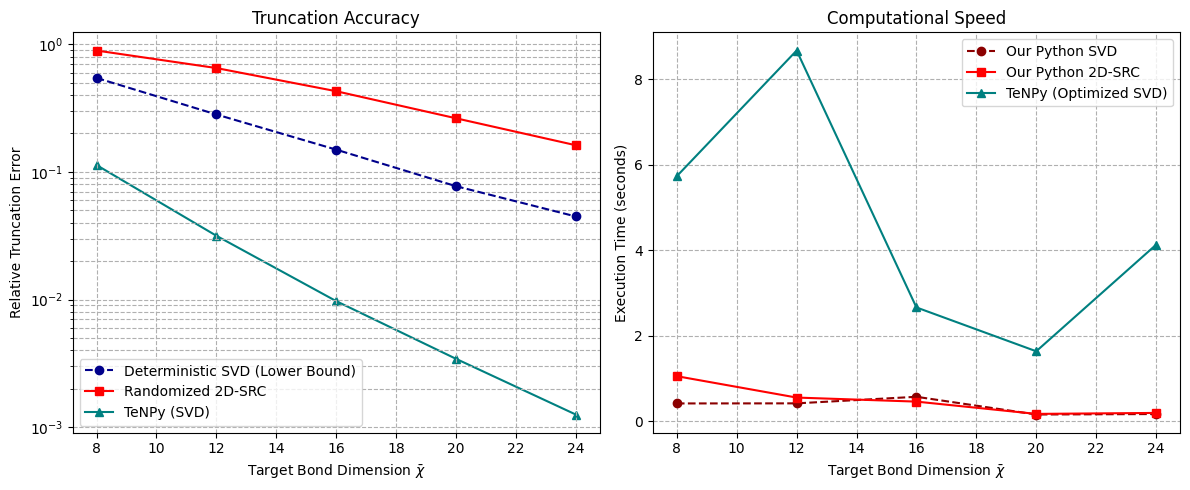

[*] Saved benchmark plots to 'tenpy_comparison_plots.png'.


In [3]:
from tenpy.networks.site import SpinHalfSite
from tenpy.networks.mps import MPS as TenPyMPS
from tenpy.networks.mpo import MPO as TenPyMPO
import tenpy.linalg.np_conserved as npc

def benchmark_comparison():
    N = 40  # Number of sites
    d = 2   # Physical dimension
    D = 16  # MPO bond dimension
    chi = 16 # MPS bond dimension
    chi_target_values = [8, 12, 16, 20, 24]

    print("[*] Generating random 1D systems...")
    mps = generate_random_mps(N, d, chi)
    mpo = generate_random_mpo(N, d, D)

    print("[*] Computing exact MPO-MPS product and canonicalizing it...")
    exact_product = contract_exact(mpo, mps)
    # Left-canonicalize exact state using SVD with very large bond dimension (no truncation)
    exact_normalized = compress_deterministic_svd(exact_product, chi_target=1000, normalize=True)
    print("[+] Exact canonical state prepared and normalized.")

    results = {
        "svd": {"time": [], "error": []},
        "src": {"time": [], "error": []},
        "tenpy": {"time": [], "error": []}
    }

    # TeNPy Setup
    site = SpinHalfSite(conserve=None)
    tenpy_sites = [site] * N

    print("[*] Sweeping target bond dimensions...")
    for chi_t in chi_target_values:
        print(f"    - Testing target bond dimension = {chi_t}...")

        # 1. Deterministic SVD
        t0 = time.time()
        comp_svd = compress_deterministic_svd(exact_product, chi_t, normalize=True)
        t_svd = time.time() - t0
        overlap_svd = compute_mps_overlap(exact_normalized, comp_svd)
        err_svd = np.sqrt(max(0.0, 1.0 - abs(overlap_svd)**2))
        results["svd"]["time"].append(t_svd)
        results["svd"]["error"].append(err_svd)

        # 2. 2D Successive Randomized Compression (2D-SRC)
        t0 = time.time()
        comp_src = compress_randomized_src(mpo, mps, chi_t, oversampling=5, normalize=True)
        t_src = time.time() - t0
        overlap_src = compute_mps_overlap(exact_normalized, comp_src)
        err_src = np.sqrt(max(0.0, 1.0 - abs(overlap_src)**2))
        results["src"]["time"].append(t_src)
        results["src"]["error"].append(err_src)

        # 3. TeNPy (Optimized SVD baseline)
        t0 = time.time()
        tp_mps = TenPyMPS.from_Bflat(tenpy_sites, [t.transpose(1, 0, 2) for t in mps])
        Ws = [npc.Array.from_ndarray_trivial(t.transpose(0, 3, 1, 2), labels=['wL', 'wR', 'p', 'p*']) for t in mpo]
        tp_mpo = TenPyMPO(tenpy_sites, Ws, IdL=0, IdR=0)
        tp_mpo.apply(tp_mps, {"compression_method": "SVD", "trunc_params": {"chi_max": chi_t}})
        t_tenpy = time.time() - t0
        results["tenpy"]["time"].append(t_tenpy)

        # Convert compressed TeNPy state back to NumPy, normalize it, and check truncation error
        comp_tenpy = [tp_mps.get_B(i).to_ndarray() for i in range(N)]
        comp_tenpy_norm = compress_deterministic_svd(comp_tenpy, chi_target=1000, normalize=True)
        overlap_tenpy = compute_mps_overlap(exact_normalized, comp_tenpy_norm)
        err_tenpy = np.sqrt(max(0.0, 1.0 - abs(overlap_tenpy)**2))
        results["tenpy"]["error"].append(err_tenpy)

        print(f"      -> SVD error: {err_svd:.4e}, time: {t_svd:.4f}s")
        print(f"      -> 2D-SRC error: {err_src:.4e}, time: {t_src:.4f}s")
        print(f"      -> TeNPy error: {err_tenpy:.4e}, time: {t_tenpy:.4f}s")

    # -------------------------------------------------------------------------
    # Plotting
    # -------------------------------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy comparison
    axs[0].plot(chi_target_values, results["svd"]["error"], 'o--', color='darkblue', label='Deterministic SVD (Lower Bound)', zorder=2)
    axs[0].plot(chi_target_values, results["src"]["error"], 's-', color='red', label='Randomized 2D-SRC', zorder=3)
    axs[0].plot(chi_target_values, results["tenpy"]["error"], '^-', color='teal', label='TeNPy (SVD)', zorder=1)
    axs[0].set_yscale('log')
    axs[0].set_xlabel(r'Target Bond Dimension $\bar{\chi}$')
    axs[0].set_ylabel('Relative Truncation Error')
    axs[0].set_title('Truncation Accuracy')
    axs[0].grid(True, which="both", ls="--")
    axs[0].legend()

    # Runtime comparison
    axs[1].plot(chi_target_values, results["svd"]["time"], 'o--', color='darkred', label='Our Python SVD')
    axs[1].plot(chi_target_values, results["src"]["time"], 's-', color='red', label='Our Python 2D-SRC')
    axs[1].plot(chi_target_values, results["tenpy"]["time"], '^-', color='teal', label='TeNPy (Optimized SVD)')
    axs[1].set_xlabel(r'Target Bond Dimension $\bar{\chi}$')
    axs[1].set_ylabel('Execution Time (seconds)')
    axs[1].set_title('Computational Speed')
    axs[1].grid(True, ls="--")
    axs[1].legend()

    plt.tight_layout()
    plt.savefig('tenpy_comparison_plots.png', dpi=150)
    plt.show()
    print("[*] Saved benchmark plots to 'tenpy_comparison_plots.png'.")

benchmark_comparison()